#  <span style="color:red">ASMAE AIT OUALI</span>

##  <span style="color:blue">  Modélisation de la Performance des Étudiants avec Régression </span>

##  Objectif

Ce projet vise à prédire la performance académique des étudiants (`overall_score`) en utilisant différents modèles de régression implémentés avec la bibliothèque **Scikit-Learn**.

Nous comparons trois approches :

- Régression Linéaire Simple  
- Régression Linéaire Multiple  
- Régression Polynomiale  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Modèles sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Charger le dataset
df = pd.read_csv(r"C:\Users\majid\Downloads\Student_Performance.csv")

# Aperçu
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [3]:
# Suppression des colonnes inutiles
df = df.drop(columns=["student_id", "final_grade"])

# Encodage des variables catégorielles (one-hot encoding)
df = pd.get_dummies(df, drop_first=True)

# Vérification
print(df.head())

   age  study_hours  attendance_percentage  math_score  science_score  \
0   14          3.1                   84.3        42.7           55.4   
1   18          3.7                   87.8        57.6           68.8   
2   17          7.9                   65.5        84.8           95.0   
3   16          1.1                   58.1        44.4           27.5   
4   16          1.3                   61.0         8.9           32.7   

   english_score  overall_score  gender_male  gender_other  \
0           57.0           53.1         True         False   
1           64.8           61.3        False         False   
2           79.2           89.6        False         False   
3           54.7           41.6        False          True   
4           30.0           25.4        False         False   

   school_type_public  ...  internet_access_yes  travel_time_30-60 min  \
0                True  ...                 True                  False   
1                True  ...              

In [4]:
# Variable cible
y = df["overall_score"]

# Variables explicatives
X = df.drop("overall_score", axis=1)

In [5]:
#Les données sont divisées en deux ensembles :

#Train (80%) : utilisé pour entraîner le modèle
#Test (20%) : utilisé pour évaluer le modèle
#test_size=0.2 → 20% des données pour le test
#random_state=42 → assure la reproductibilité des résultats
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  <span style="color:blue">Régression linéaire </span>
        

##  Définition

La régression linéaire simple modélise la relation entre une seule variable explicative et la variable cible à l’aide d’une relation linéaire.
##  Formulation mathématique

$$
y = ax + b
$$

-Étudier l’impact d’une seule variable (ex: study_hours) sur la performance des étudiants

-Fournir un modèle simple et interprétable



In [6]:
# Choisir une seule feature
X_simple = df[["study_hours"]]

# Split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Modèle
model_simple = LinearRegression()

# Entraînement
model_simple.fit(X_train_s, y_train_s)

# Prédiction
y_pred_s = model_simple.predict(X_test_s)

# Évaluation
print("R² (Simple):", r2_score(y_test_s, y_pred_s))
print("MSE (Simple):", mean_squared_error(y_test_s, y_pred_s))

R² (Simple): 0.8199124383388936
MSE (Simple): 65.3846143236837


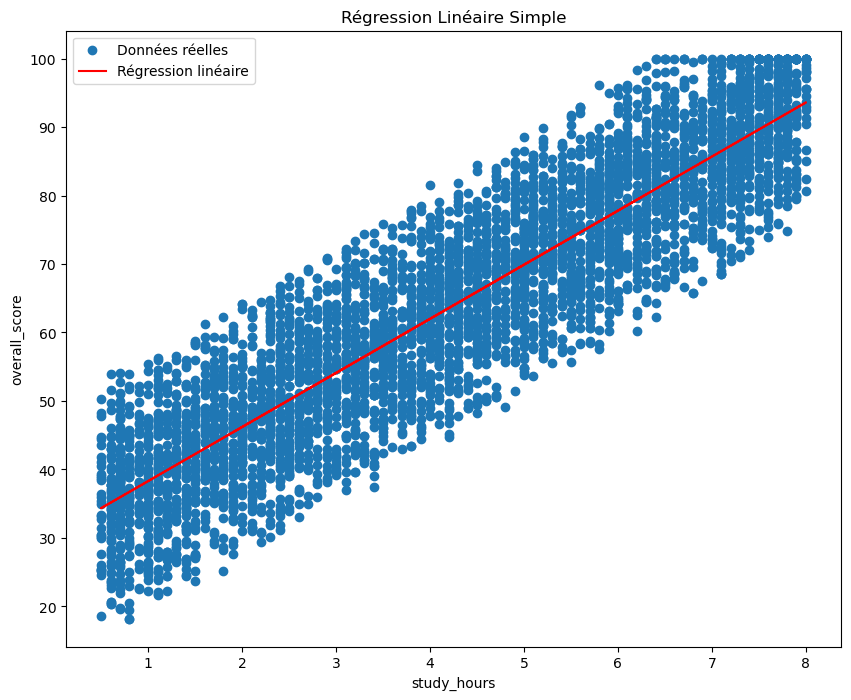

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

# Points réels
plt.scatter(X_test_s, y_test_s, label="Données réelles")

# Droite de régression
plt.plot(X_test_s, y_pred_s, color="red", label="Régression linéaire")

plt.xlabel("study_hours")
plt.ylabel("overall_score")
plt.title("Régression Linéaire Simple")
plt.legend()
plt.show()

#  <span style="color:blue">Régression multiple </span>


##  Définition

La régression linéaire multiple utilise plusieurs variables explicatives pour prédire la variable cible.
##  Formulation mathématique
$$
\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b
$$

ou sous forme matricielle :
    
  $$
\hat{y} = Xw + b
$$  
où :

-Exploiter plusieurs variables simultanément

-Améliorer la performance du modèle


In [8]:
# Modèle
model_multi = LinearRegression()

# Entraînement
model_multi.fit(X_train, y_train)

# Prédiction
y_pred_multi = model_multi.predict(X_test)

# Évaluation
print("R² (Multiple):", r2_score(y_test, y_pred_multi))
print("MSE (Multiple):", mean_squared_error(y_test, y_pred_multi))

R² (Multiple): 0.952978054123655
MSE (Multiple): 17.07231619727101


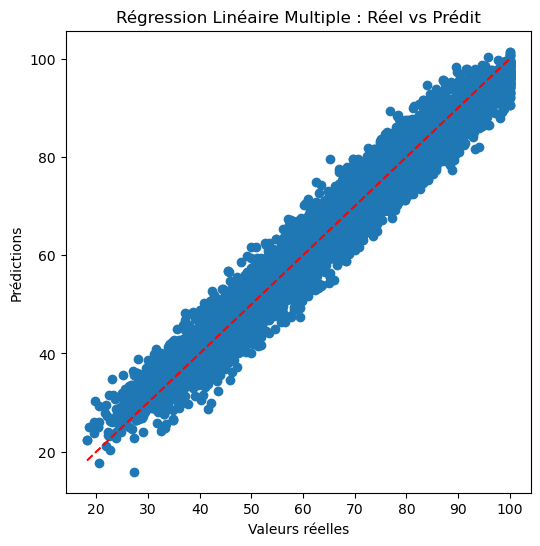

In [9]:
import matplotlib.pyplot as plt

# Prédictions du modèle
y_pred_multi = model_multi.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_multi)

# Ligne idéale (y = x)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Régression Linéaire Multiple : Réel vs Prédit")
plt.show()

#  <span style="color:blue">Régression polynomiale </span>


##  Définition

La régression polynomiale permet de modéliser des relations non linéaires en ajoutant des termes polynomiaux aux variables d’entrée.
##  Formulation mathématique

$$
y = a_0 + a_1 x + a_2 x^2 + a_3 x^3 + \cdots + a_d x^d
$$

où 

Capturer des relations non linéaires entre les variables

Améliorer la flexibilité du modèle


In [10]:
# Feature
X_poly = df[["study_hours"]]

# Split
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# Transformation polynomiale (degré 3)
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train_p)
X_test_poly = poly.transform(X_test_p)

# Modèle
model_poly = LinearRegression()

# Entraînement
model_poly.fit(X_train_poly, y_train_p)

# Prédiction
y_pred_poly = model_poly.predict(X_test_poly)

# Évaluation
print("R² (Polynomial):", r2_score(y_test_p, y_pred_poly))
print("MSE (Polynomial):", mean_squared_error(y_test_p, y_pred_poly))

R² (Polynomial): 0.8197685803937724
MSE (Polynomial): 65.43684500620495


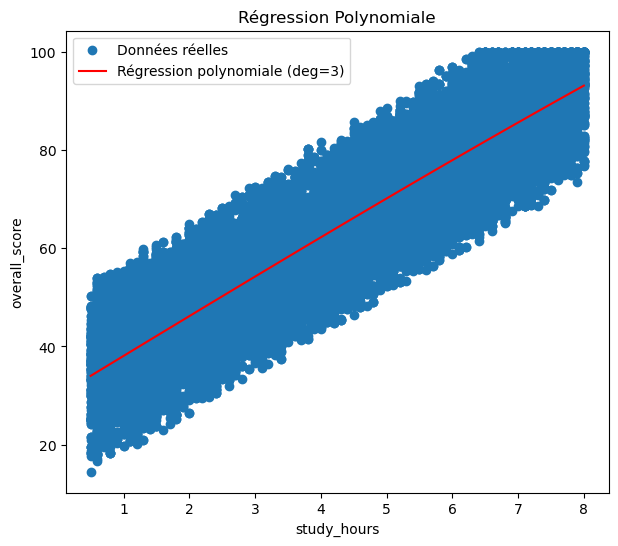

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Créer une grille
X_grid = np.linspace(X_poly.min(), X_poly.max(), 100)

# Convertir en DataFrame avec le même nom de feature
X_grid_df = pd.DataFrame(X_grid, columns=["study_hours"])

# Transformation polynomiale
X_grid_poly = poly.transform(X_grid_df)

# Prédictions
y_grid_pred = model_poly.predict(X_grid_poly)

# Plot
plt.figure(figsize=(7,6))

# Données réelles
plt.scatter(X_poly, y, label="Données réelles")

# Courbe du modèle
plt.plot(X_grid, y_grid_pred, color="red", label="Régression polynomiale (deg=3)")

plt.xlabel("study_hours")
plt.ylabel("overall_score")
plt.title("Régression Polynomiale")
plt.legend()
plt.show()